# **Oil Price Forecasting: ARIMA and LSTM Models**

## **1. Import Required Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Time series analysis libraries
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from itertools import product

# LSTM and deep learning libraries
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

## **2. Data Loading and Initial Exploration**

In [2]:
# Load the oil price data
df = pd.read_csv('oil_prices_2426.csv')

# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'], format='%d/%m/%Y')
df.set_index('date', inplace=True)
df.columns = ['price']

# Display basic information
print('Dataset Shape:', df.shape)
print('\nFirst 5 rows:')
print(df.head())
print('\nLast 5 rows:')
print(df.tail())
print('\nBasic Statistics:')
print(df.describe())
print('\nDate Range:')
print(f'Start: {df.index.min()}')
print(f'End: {df.index.max()}')
print(f'Total Days: {len(df)}')

Dataset Shape: (500, 1)

First 5 rows:
            price
date             
2024-09-21  32.10
2024-09-22  32.25
2024-09-23  31.07
2024-09-24  31.50
2024-09-25  32.21

Last 5 rows:
             price
date              
2026-01-29  120.76
2026-01-30  121.07
2026-01-31  120.97
2026-02-01  119.25
2026-02-02  118.92

Basic Statistics:
            price
count  500.000000
mean    75.873980
std     42.912398
min     16.480000
25%     35.372500
50%     64.290000
75%    111.572500
max    158.780000

Date Range:
Start: 2024-09-21 00:00:00
End: 2026-02-02 00:00:00
Total Days: 500


## **3. Exploratory Data Analysis and Visualization**

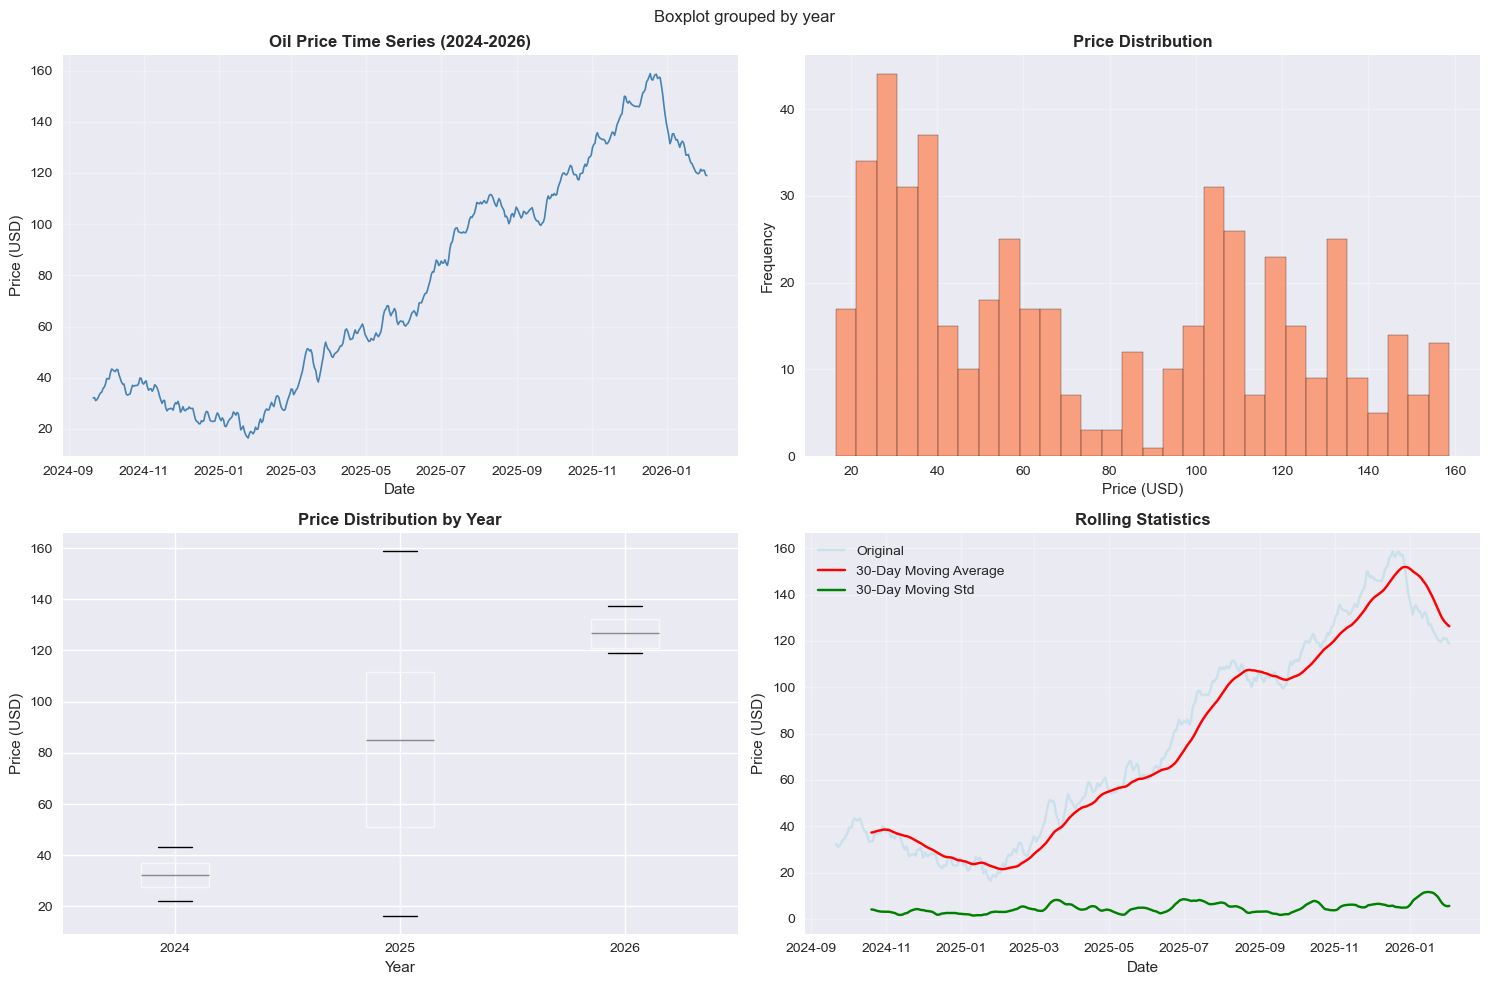

EDA Summary:
Mean Price: $75.87
Std Deviation: $42.91
Min Price: $16.48
Max Price: $158.78
Price Range: $142.30


In [3]:
# Time series plot
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Original time series
axes[0, 0].plot(df.index, df['price'], color='steelblue', linewidth=1.2)
axes[0, 0].set_title('Oil Price Time Series (2024-2026)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Price (USD)')
axes[0, 0].grid(True, alpha=0.3)

# Distribution histogram
axes[0, 1].hist(df['price'], bins=30, color='coral', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Price Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Price (USD)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].grid(True, alpha=0.3)

# Box plot by year
df['year'] = df.index.year
df.boxplot(column='price', by='year', ax=axes[1, 0])
axes[1, 0].set_title('Price Distribution by Year', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('Price (USD)')

# Rolling statistics
rolling_mean = df['price'].rolling(window=30).mean()
rolling_std = df['price'].rolling(window=30).std()
axes[1, 1].plot(df.index, df['price'], color='lightblue', alpha=0.5, label='Original')
axes[1, 1].plot(df.index, rolling_mean, color='red', label='30-Day Moving Average')
axes[1, 1].plot(df.index, rolling_std, color='green', label='30-Day Moving Std')
axes[1, 1].set_title('Rolling Statistics', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('Price (USD)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=300, bbox_inches='tight')
plt.show()

print('EDA Summary:')
print(f'Mean Price: ${df["price"].mean():.2f}')
print(f'Std Deviation: ${df["price"].std():.2f}')
print(f'Min Price: ${df["price"].min():.2f}')
print(f'Max Price: ${df["price"].max():.2f}')
print(f'Price Range: ${df["price"].max() - df["price"].min():.2f}')

## **4. Stationarity Testing**

In [4]:
# Function to perform stationarity tests
def stationarity_tests(series, title='Time Series'):
    print(f'\n{title}')
    print('=' * 60)
    
    # Augmented Dickey-Fuller Test
    adf_result = adfuller(series.dropna())
    print('Augmented Dickey-Fuller Test:')
    print(f'  ADF Statistic: {adf_result[0]:.6f}')
    print(f'  p-value: {adf_result[1]:.6f}')
    print(f'  Critical Values:')
    for key, value in adf_result[4].items():
        print(f'    {key}: {value:.4f}')
    if adf_result[1] <= 0.05:
        print('  Result: Series is STATIONARY (reject null hypothesis)')
    else:
        print('  Result: Series is NON-STATIONARY (fail to reject null hypothesis)')
    
    # KPSS Test
    kpss_result = kpss(series.dropna(), regression='c')
    print('\nKPSS Test:')
    print(f'  KPSS Statistic: {kpss_result[0]:.6f}')
    print(f'  p-value: {kpss_result[1]:.6f}')
    print(f'  Critical Values:')
    for key, value in kpss_result[3].items():
        print(f'    {key}: {value:.4f}')
    if kpss_result[1] > 0.05:
        print('  Result: Series is STATIONARY (fail to reject null hypothesis)')
    else:
        print('  Result: Series is NON-STATIONARY (reject null hypothesis)')

# Test original series
stationarity_tests(df['price'], 'Original Price Series')


Original Price Series
Augmented Dickey-Fuller Test:
  ADF Statistic: -0.546234
  p-value: 0.882674
  Critical Values:
    1%: -3.4440
    5%: -2.8676
    10%: -2.5700
  Result: Series is NON-STATIONARY (fail to reject null hypothesis)

KPSS Test:
  KPSS Statistic: 3.705619
  p-value: 0.010000
  Critical Values:
    10%: 0.3470
    5%: 0.4630
    2.5%: 0.5740
    1%: 0.7390
  Result: Series is NON-STATIONARY (reject null hypothesis)


/var/folders/bn/b8308xfx04g235ttkq_q6vym0000gn/T/ipykernel_32800/90451144.py:20: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(series.dropna(), regression='c')


## **5. ACF and PACF Analysis**

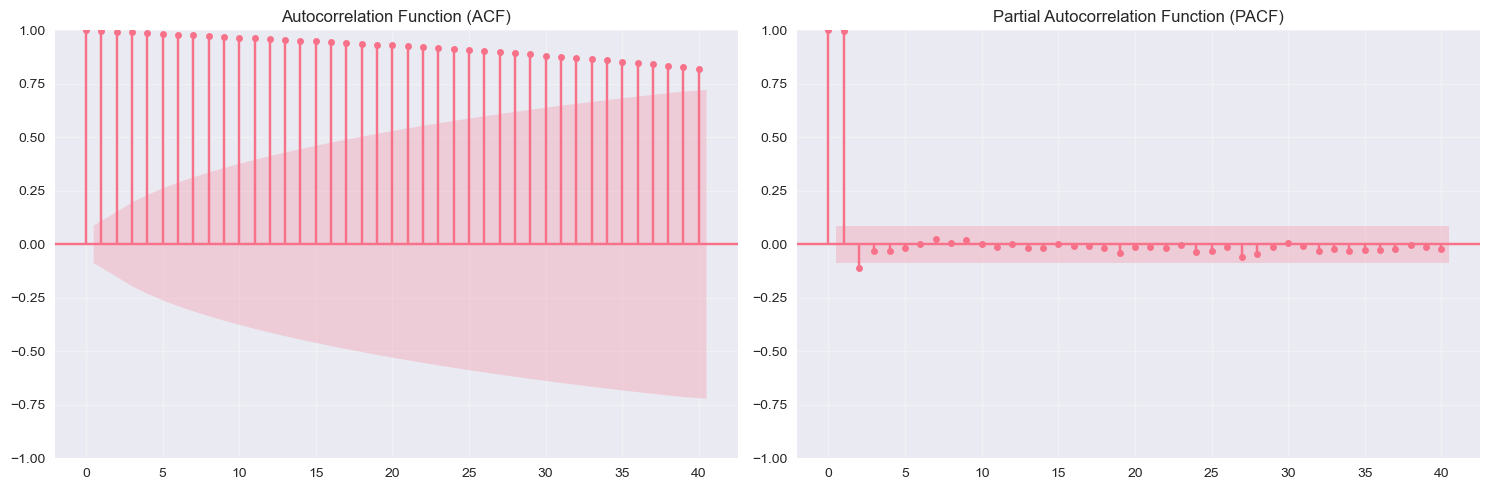

In [5]:
# ACF and PACF plots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

plot_acf(df['price'].dropna(), lags=40, ax=axes[0], title='Autocorrelation Function (ACF)')
axes[0].grid(True, alpha=0.3)

plot_pacf(df['price'].dropna(), lags=40, ax=axes[1], title='Partial Autocorrelation Function (PACF)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('acf_pacf_original.png', dpi=300, bbox_inches='tight')
plt.show()

## **6. Differencing to Achieve Stationarity**

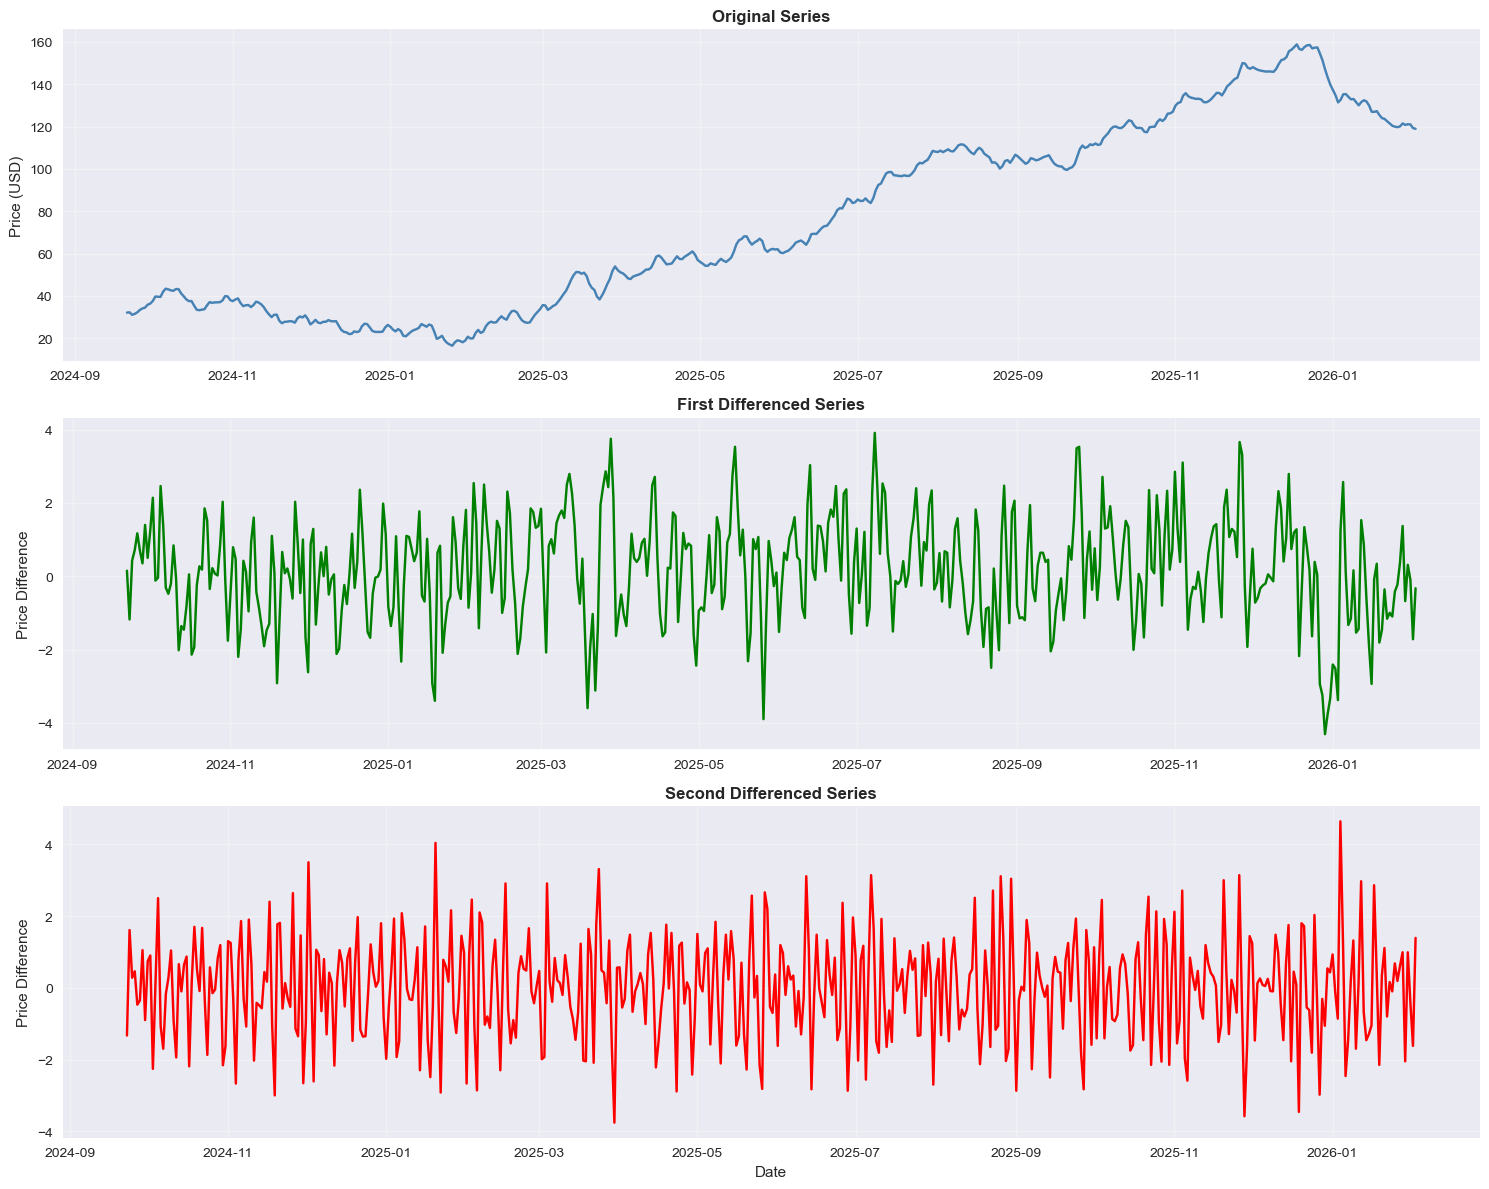


First Differenced Series
Augmented Dickey-Fuller Test:
  ADF Statistic: -4.541460
  p-value: 0.000165
  Critical Values:
    1%: -3.4440
    5%: -2.8676
    10%: -2.5700
  Result: Series is STATIONARY (reject null hypothesis)

KPSS Test:
  KPSS Statistic: 0.190341
  p-value: 0.100000
  Critical Values:
    10%: 0.3470
    5%: 0.4630
    2.5%: 0.5740
    1%: 0.7390
  Result: Series is STATIONARY (fail to reject null hypothesis)

Second Differenced Series
Augmented Dickey-Fuller Test:
  ADF Statistic: -9.004202
  p-value: 0.000000
  Critical Values:
    1%: -3.4440
    5%: -2.8676
    10%: -2.5700
  Result: Series is STATIONARY (reject null hypothesis)

KPSS Test:
  KPSS Statistic: 0.128994
  p-value: 0.100000
  Critical Values:
    10%: 0.3470
    5%: 0.4630
    2.5%: 0.5740
    1%: 0.7390
  Result: Series is STATIONARY (fail to reject null hypothesis)


/var/folders/bn/b8308xfx04g235ttkq_q6vym0000gn/T/ipykernel_32800/90451144.py:20: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(series.dropna(), regression='c')
/var/folders/bn/b8308xfx04g235ttkq_q6vym0000gn/T/ipykernel_32800/90451144.py:20: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(series.dropna(), regression='c')


In [6]:
# First differencing
df['price_diff1'] = df['price'].diff()

# Second differencing
df['price_diff2'] = df['price'].diff().diff()

# Plot differenced series
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

axes[0].plot(df.index, df['price'], color='steelblue')
axes[0].set_title('Original Series', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Price (USD)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(df.index, df['price_diff1'], color='green')
axes[1].set_title('First Differenced Series', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Price Difference')
axes[1].grid(True, alpha=0.3)

axes[2].plot(df.index, df['price_diff2'], color='red')
axes[2].set_title('Second Differenced Series', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Price Difference')
axes[2].set_xlabel('Date')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('differencing.png', dpi=300, bbox_inches='tight')
plt.show()

# Test stationarity of differenced series
stationarity_tests(df['price_diff1'], 'First Differenced Series')
stationarity_tests(df['price_diff2'], 'Second Differenced Series')

## **7. ACF and PACF of Differenced Series**

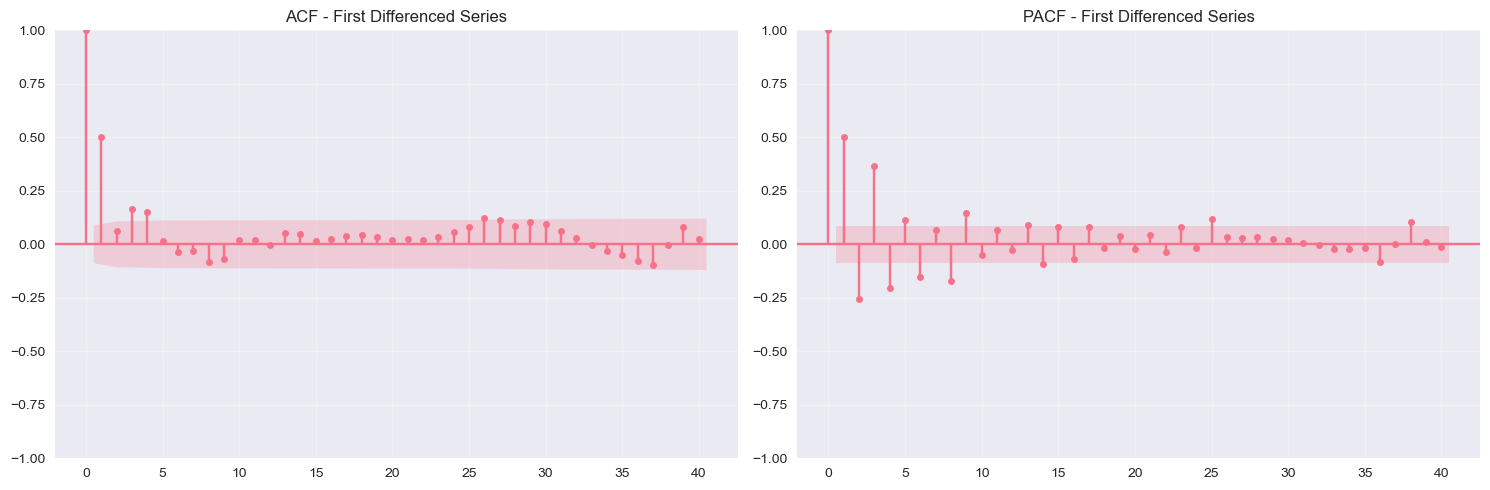

In [7]:
# ACF and PACF of first differenced series
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

plot_acf(df['price_diff1'].dropna(), lags=40, ax=axes[0], 
         title='ACF - First Differenced Series')
axes[0].grid(True, alpha=0.3)

plot_pacf(df['price_diff1'].dropna(), lags=40, ax=axes[1], 
          title='PACF - First Differenced Series')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('acf_pacf_differenced.png', dpi=300, bbox_inches='tight')
plt.show()

## **8. ARIMA Model Parameter Optimization**

In [8]:
# Grid search for optimal ARIMA parameters
p_range = range(0, 9)
d_range = range(0, 3)
q_range = range(0, 9)

best_aic = float('inf')
best_params = None
best_model = None
results_list = []

print('Searching for optimal ARIMA parameters...')
print('Testing p=[0-8], d=[0-2], q=[0-8]')
print('=' * 60)

for p, d, q in product(p_range, d_range, q_range):
    try:
        model = ARIMA(df['price'], order=(p, d, q))
        fitted_model = model.fit()
        aic = fitted_model.aic
        bic = fitted_model.bic
        
        results_list.append({
            'p': p, 'd': d, 'q': q,
            'AIC': aic, 'BIC': bic,
            'log_likelihood': fitted_model.llf
        })
        
        if aic < best_aic:
            best_aic = aic
            best_params = (p, d, q)
            best_model = fitted_model
            
    except Exception as e:
        continue

# Convert results to DataFrame
results_df = pd.DataFrame(results_list)
results_df = results_df.sort_values('AIC').reset_index(drop=True)

print(f'\nBest ARIMA Parameters: p={best_params[0]}, d={best_params[1]}, q={best_params[2]}')
print(f'Best AIC: {best_aic:.4f}')
print(f'Best BIC: {best_model.bic:.4f}')
print('\nTop 10 Models by AIC:')
print(results_df.head(10).to_string(index=False))

Searching for optimal ARIMA parameters...
Testing p=[0-8], d=[0-2], q=[0-8]


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  


Best ARIMA Parameters: p=2, d=2, q=7
Best AIC: 1429.2166
Best BIC: 1471.3226

Top 10 Models by AIC:
 p  d  q         AIC         BIC  log_likelihood
 2  2  7 1429.216571 1471.322572     -704.608286
 4  1  5 1429.771989 1471.898050     -704.885994
 0  1  5 1429.897917 1455.173554     -708.948958
 1  1  4 1430.457760 1455.733397     -709.228880
 4  1  8 1430.507906 1485.271786     -702.253953
 2  1  4 1430.851612 1460.339854     -708.425806
 5  1  5 1430.983812 1477.322479     -704.491906
 4  1  1 1431.110534 1456.386170     -709.555267
 0  1  6 1431.355376 1460.843618     -708.677688
 3  1  3 1431.692968 1461.181210     -708.846484


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## **9. Best ARIMA Model Fitting and Diagnostics**

In [9]:
# Fit the best ARIMA model
print(f'Fitting ARIMA{best_params} model...')
arima_model = ARIMA(df['price'], order=best_params)
arima_fitted = arima_model.fit()

print('\nModel Summary:')
print(arima_fitted.summary())

# Get fitted values and residuals
fitted_values = arima_fitted.fittedvalues
residuals = arima_fitted.resid

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


Fitting ARIMA(2, 2, 7) model...

Model Summary:
                               SARIMAX Results                                
Dep. Variable:                  price   No. Observations:                  500
Model:                 ARIMA(2, 2, 7)   Log Likelihood                -704.608
Date:                Fri, 06 Mar 2026   AIC                           1429.217
Time:                        00:20:32   BIC                           1471.323
Sample:                    09-21-2024   HQIC                          1445.742
                         - 02-02-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.1800      0.032    -37.396      0.000      -1.242      -1.118
ar.L2         -0.9181      0.032    -28.763      0.000      -0.981      -0.856
ma.L

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## **10. ARIMA Model Diagnostics and Residual Analysis**

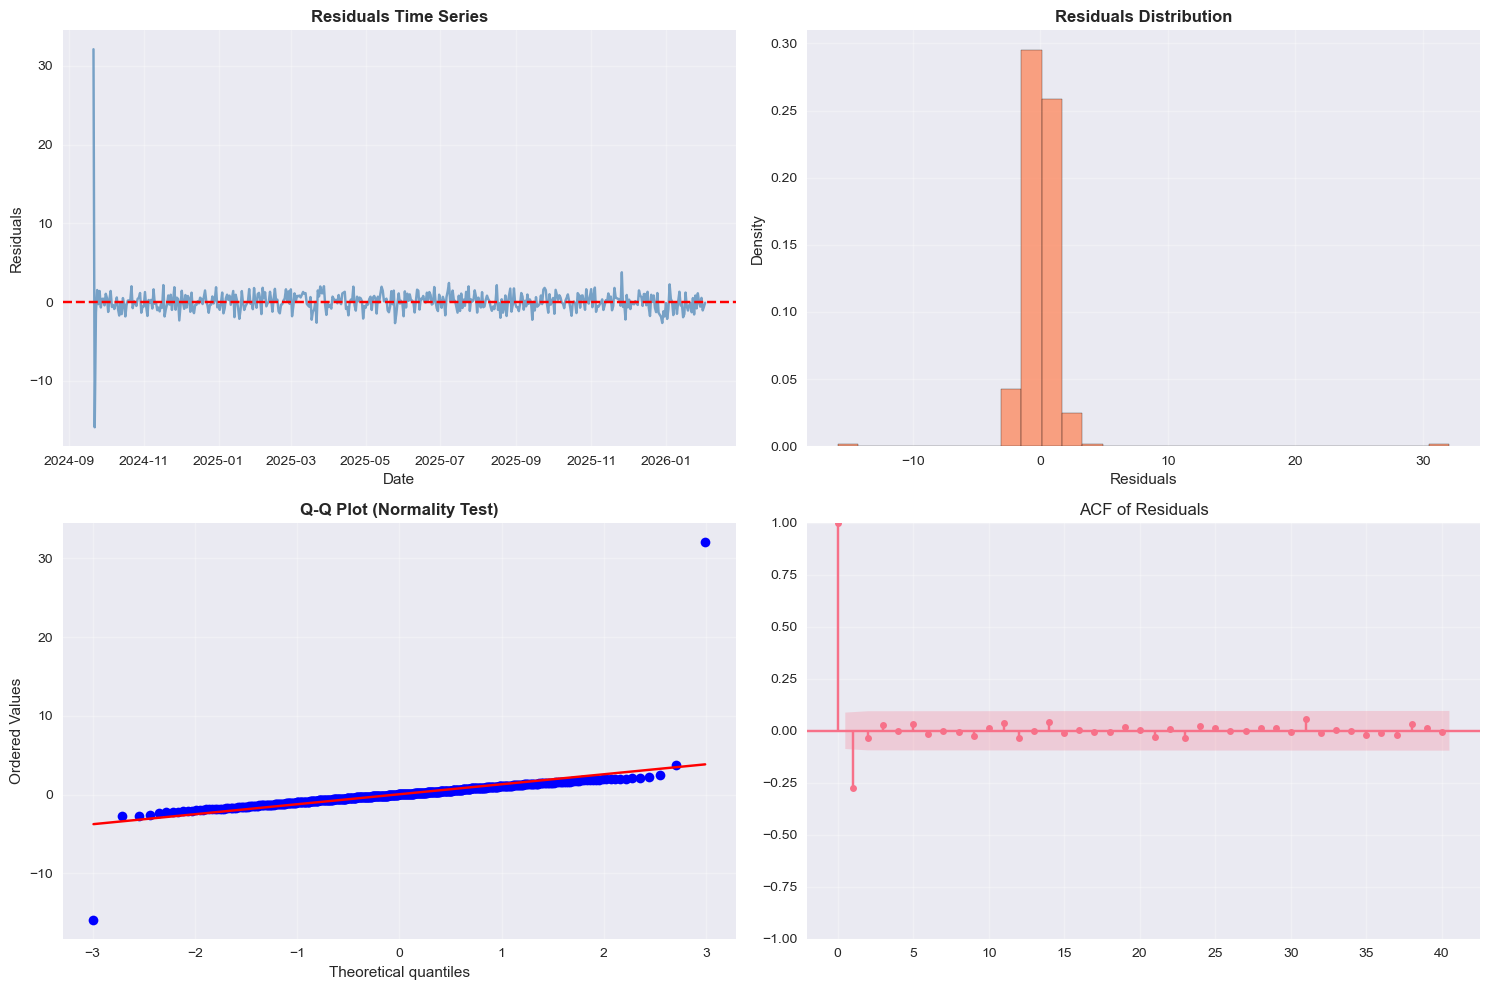


Ljung-Box Test on Residuals (Testing for White Noise):
      lb_stat     lb_pvalue
1   38.217753  6.327413e-10
2   38.841650  3.678264e-09
3   39.249389  1.536845e-08
4   39.251900  6.179768e-08
5   39.758783  1.670315e-07
6   39.904538  4.756198e-07
7   39.907864  1.310944e-06
8   39.940990  3.285830e-06
9   40.202522  6.982650e-06
10  40.274994  1.515565e-05

Residual Statistics:
Mean: 0.044833
Std Dev: 1.8863
Skewness: 8.6177
Kurtosis: 174.9314

Shapiro-Wilk Test:
Statistic: 0.462824
p-value: 0.000000
Residuals may not be normally distributed


In [10]:
# Residual diagnostics
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Residual time series
axes[0, 0].plot(df.index, residuals, color='steelblue', alpha=0.7)
axes[0, 0].axhline(y=0, color='red', linestyle='--')
axes[0, 0].set_title('Residuals Time Series', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].grid(True, alpha=0.3)

# Residual distribution
axes[0, 1].hist(residuals, bins=30, color='coral', edgecolor='black', alpha=0.7, density=True)
axes[0, 1].set_title('Residuals Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Residuals')
axes[0, 1].set_ylabel('Density')
axes[0, 1].grid(True, alpha=0.3)

# Q-Q plot
from scipy import stats
stats.probplot(residuals, dist='norm', plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot (Normality Test)', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# ACF of residuals
plot_acf(residuals.dropna(), lags=40, ax=axes[1, 1], title='ACF of Residuals')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('arima_residual_diagnostics.png', dpi=300, bbox_inches='tight')
plt.show()

# Ljung-Box test on residuals
lb_test = acorr_ljungbox(residuals.dropna(), lags=10, return_df=True)
print('\nLjung-Box Test on Residuals (Testing for White Noise):')
print(lb_test.to_string())

# Residual statistics
print('\nResidual Statistics:')
print(f'Mean: {residuals.mean():.6f}')
print(f'Std Dev: {residuals.std():.4f}')
print(f'Skewness: {stats.skew(residuals):.4f}')
print(f'Kurtosis: {stats.kurtosis(residuals):.4f}')

# Shapiro-Wilk test for normality
shapiro_stat, shapiro_p = stats.shapiro(residuals.dropna()[:min(5000, len(residuals))])
print(f'\nShapiro-Wilk Test:')
print(f'Statistic: {shapiro_stat:.6f}')
print(f'p-value: {shapiro_p:.6f}')
if shapiro_p > 0.05:
    print('Residuals appear to be normally distributed')
else:
    print('Residuals may not be normally distributed')

## **11. ARIMA Model Fit Visualization**

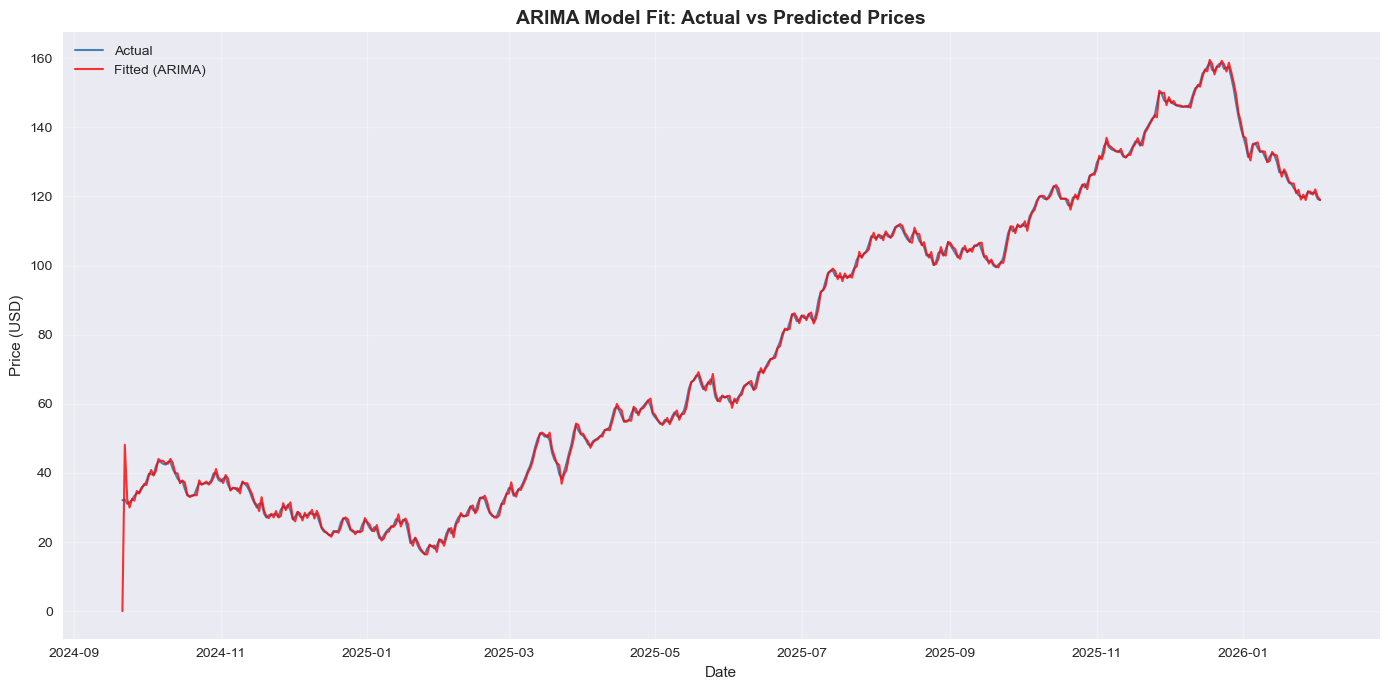

ARIMA In-Sample Performance Metrics:
RMSE: 1.8850
MAE: 0.8875
MAPE: 1.8274%


In [11]:
# Plot fitted vs actual values
plt.figure(figsize=(14, 7))
plt.plot(df.index, df['price'], label='Actual', color='steelblue', linewidth=1.5)
plt.plot(df.index, fitted_values, label='Fitted (ARIMA)', color='red', 
         linewidth=1.5, alpha=0.8)
plt.title('ARIMA Model Fit: Actual vs Predicted Prices', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('arima_model_fit.png', dpi=300, bbox_inches='tight')
plt.show()

# Calculate in-sample metrics
from sklearn.metrics import mean_absolute_percentage_error

# Remove NaN values for metric calculation
valid_idx = ~(np.isnan(df['price']) | np.isnan(fitted_values))
actual_clean = df['price'][valid_idx]
fitted_clean = fitted_values[valid_idx]

arima_rmse = np.sqrt(mean_squared_error(actual_clean, fitted_clean))
arima_mae = mean_absolute_error(actual_clean, fitted_clean)
arima_mape = mean_absolute_percentage_error(actual_clean, fitted_clean) * 100

print('ARIMA In-Sample Performance Metrics:')
print(f'RMSE: {arima_rmse:.4f}')
print(f'MAE: {arima_mae:.4f}')
print(f'MAPE: {arima_mape:.4f}%')

## **12. ARIMA 24-Month Forecast with Confidence Intervals**

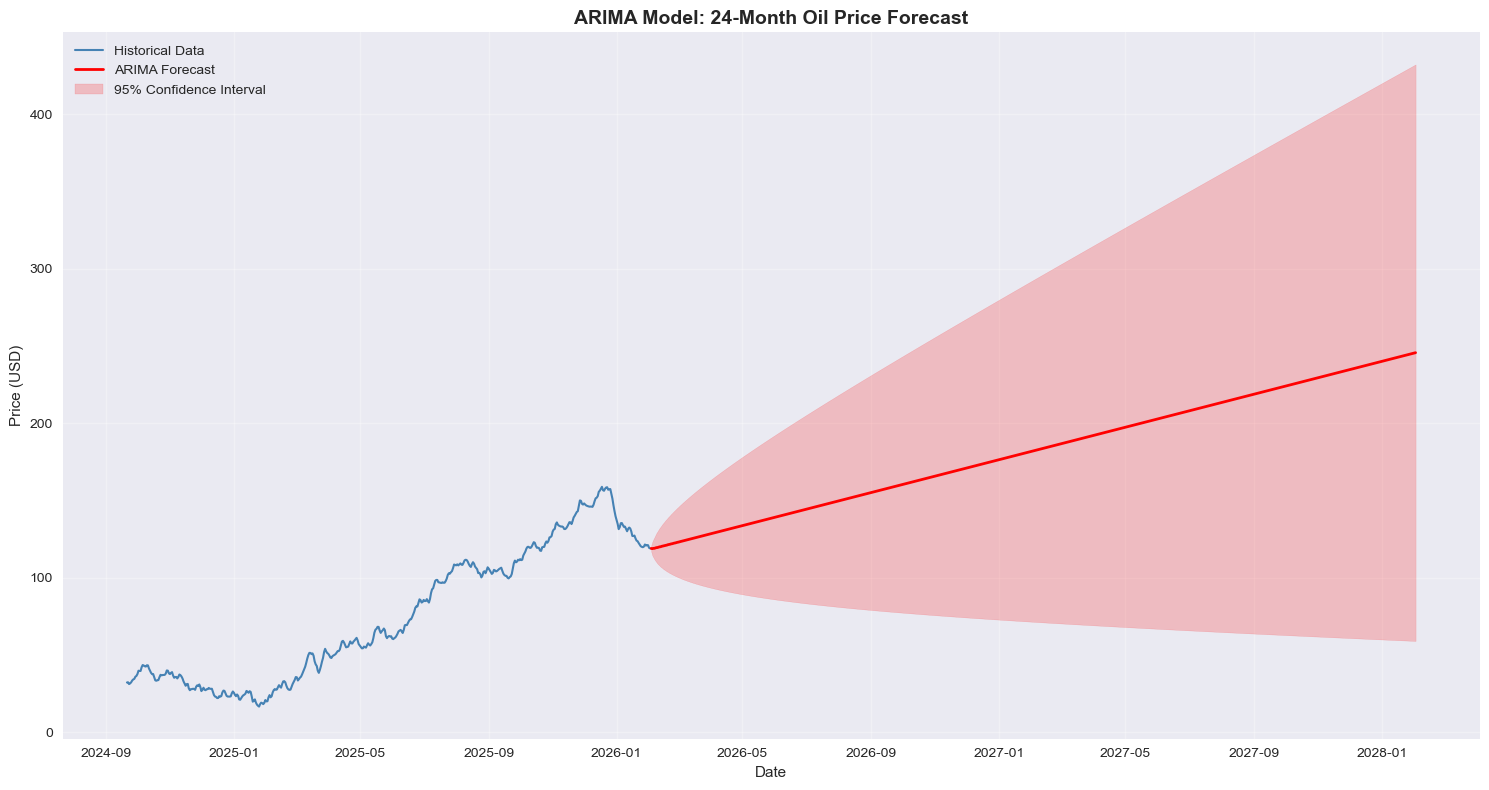

ARIMA 24-Month Forecast Summary:
Forecast Start: 2026-02-03
Forecast End: 2028-02-02

Forecast Statistics:
  Mean Forecast: $182.06
  Min Forecast: $118.75
  Max Forecast: $245.63
  Final Forecast: $245.63

Confidence Intervals (final forecast):
  Lower 95%: $59.00
  Point Estimate: $245.63
  Upper 95%: $432.26


In [12]:
# Generate 24-month (730 days) forecast
forecast_steps = 730

# Get forecast
forecast_result = arima_fitted.get_forecast(steps=forecast_steps)
forecast_mean = forecast_result.predicted_mean
forecast_ci = forecast_result.conf_int()

# Create future date index
last_date = df.index[-1]
future_dates = pd.date_range(start=last_date + timedelta(days=1), 
                             periods=forecast_steps, freq='D')

# Plot forecast
plt.figure(figsize=(15, 8))

# Plot historical data
plt.plot(df.index, df['price'], label='Historical Data', 
         color='steelblue', linewidth=1.5)

# Plot forecast
plt.plot(future_dates, forecast_mean, label='ARIMA Forecast', 
         color='red', linewidth=2)

# Plot confidence intervals
plt.fill_between(future_dates, 
                 forecast_ci.iloc[:, 0], 
                 forecast_ci.iloc[:, 1],
                 color='red', alpha=0.2, label='95% Confidence Interval')

plt.title('ARIMA Model: 24-Month Oil Price Forecast', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('arima_forecast.png', dpi=300, bbox_inches='tight')
plt.show()

# Print forecast summary
print('ARIMA 24-Month Forecast Summary:')
print('=' * 60)
print(f'Forecast Start: {future_dates[0].strftime("%Y-%m-%d")}')
print(f'Forecast End: {future_dates[-1].strftime("%Y-%m-%d")}')
print(f'\nForecast Statistics:')
print(f'  Mean Forecast: ${forecast_mean.mean():.2f}')
print(f'  Min Forecast: ${forecast_mean.min():.2f}')
print(f'  Max Forecast: ${forecast_mean.max():.2f}')
print(f'  Final Forecast: ${forecast_mean.iloc[-1]:.2f}')
print(f'\nConfidence Intervals (final forecast):')
print(f'  Lower 95%: ${forecast_ci.iloc[-1, 0]:.2f}')
print(f'  Point Estimate: ${forecast_mean.iloc[-1]:.2f}')
print(f'  Upper 95%: ${forecast_ci.iloc[-1, 1]:.2f}')

## **13. LSTM Data Preparation**

In [13]:
# Prepare data for LSTM
def create_lstm_dataset(data, lookback_window):
    X, y = [], []
    for i in range(lookback_window, len(data)):
        X.append(data[i-lookback_window:i])
        y.append(data[i])
    return np.array(X), np.array(y)

# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df[['price']])

# Define lookback window
lookback_window = 60

# Create dataset
X, y = create_lstm_dataset(scaled_data, lookback_window)

# Split into train and test sets (80-20 split)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f'Data shapes:')
print(f'X_train: {X_train.shape}')
print(f'X_test: {X_test.shape}')
print(f'y_train: {y_train.shape}')
print(f'y_test: {y_test.shape}')

# Reshape for LSTM [samples, time steps, features]
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print(f'\nReshaped for LSTM:')
print(f'X_train: {X_train.shape}')
print(f'X_test: {X_test.shape}')

Data shapes:
X_train: (352, 60, 1)
X_test: (88, 60, 1)
y_train: (352, 1)
y_test: (88, 1)

Reshaped for LSTM:
X_train: (352, 60, 1)
X_test: (88, 60, 1)


## **14. LSTM Model Architecture and Training**

In [14]:
# Build LSTM model
def build_lstm_model(input_shape, units=[50, 50], dropout_rate=0.2):
    model = Sequential()
    
    # First LSTM layer
    model.add(LSTM(units=units[0], return_sequences=True, 
                   input_shape=input_shape))
    model.add(Dropout(dropout_rate))
    
    # Second LSTM layer
    model.add(LSTM(units=units[1], return_sequences=False))
    model.add(Dropout(dropout_rate))
    
    # Dense layers
    model.add(Dense(units=25))
    model.add(Dense(units=1))
    
    # Compile model
    model.compile(optimizer='adam', loss='mean_squared_error')
    
    return model

# Build and compile model
lstm_model = build_lstm_model((X_train.shape[1], 1), units=[50, 50])
print('LSTM Model Architecture:')
lstm_model.summary()

2026-03-06 00:20:35.184128: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-03-06 00:20:35.184160: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-03-06 00:20:35.184163: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
I0000 00:00:1772756435.184436  559369 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1772756435.184473  559369 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


LSTM Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

## **15. LSTM Model Training**

In [15]:
# Set random seed for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Train the model
print('Training LSTM model...')
history = lstm_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stopping],
    verbose=1
)

print(f'\nTraining completed. Total epochs: {len(history.history["loss"])}')

Training LSTM model...
Epoch 1/100


2026-03-06 00:20:35.768887: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
E0000 00:00:1772756435.773825  559369 meta_optimizer.cc:967] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 113ms/step - loss: 0.0526 - val_loss: 0.0022
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0055 - val_loss: 0.0137
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0042 - val_loss: 8.8436e-04
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0034 - val_loss: 0.0022
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0026 - val_loss: 0.0016
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0026 - val_loss: 0.0013
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0024 - val_loss: 6.2759e-04
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0021 - val_loss: 0.0025
Epoch 9/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0024 - val_loss: 0.0011
Epoch 10/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0024 - val_loss: 0.0028
Epoch 11/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0025 - val_loss: 7.7655e-04
Epoch 12/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/ste

## **16. LSTM Training History Visualization**

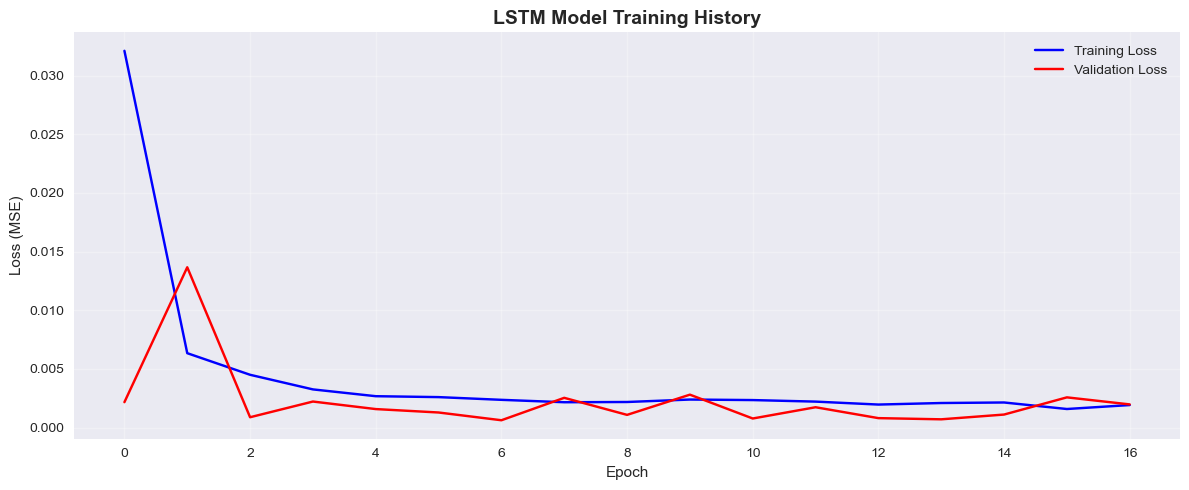

Final Training Loss: 0.001923
Final Validation Loss: 0.001978


In [16]:
# Plot training history
plt.figure(figsize=(12, 5))

plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.title('LSTM Model Training History', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('lstm_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'Final Training Loss: {history.history["loss"][-1]:.6f}')
print(f'Final Validation Loss: {history.history["val_loss"][-1]:.6f}')

## **17. LSTM Model Evaluation on Test Set**

LSTM Test Set Performance:
RMSE: 8.0742
MAE: 6.3631
MAPE: 4.7444%


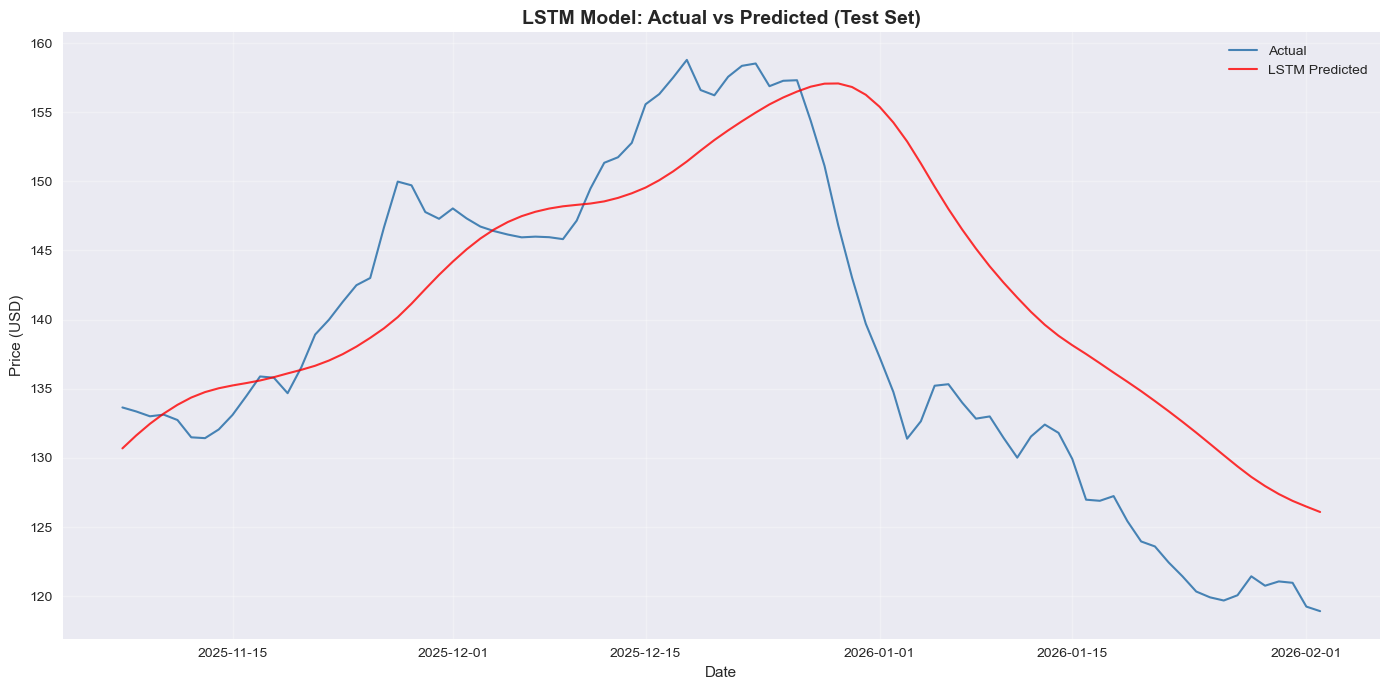

In [17]:
# Make predictions on test set
y_pred_scaled = lstm_model.predict(X_test, verbose=0)

# Inverse transform predictions and actual values
y_pred = scaler.inverse_transform(y_pred_scaled)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Calculate metrics
lstm_rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))
lstm_mae = mean_absolute_error(y_test_actual, y_pred)
lstm_mape = mean_absolute_percentage_error(y_test_actual, y_pred) * 100

print('LSTM Test Set Performance:')
print('=' * 60)
print(f'RMSE: {lstm_rmse:.4f}')
print(f'MAE: {lstm_mae:.4f}')
print(f'MAPE: {lstm_mape:.4f}%')

# Create date index for test predictions
test_start_idx = train_size + lookback_window
test_dates = df.index[test_start_idx:test_start_idx + len(y_pred)]

# Plot predictions vs actual
plt.figure(figsize=(14, 7))
plt.plot(test_dates, y_test_actual, label='Actual', 
         color='steelblue', linewidth=1.5)
plt.plot(test_dates, y_pred, label='LSTM Predicted', 
         color='red', linewidth=1.5, alpha=0.8)
plt.title('LSTM Model: Actual vs Predicted (Test Set)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('lstm_test_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

## **18. LSTM 24-Month Forecast with Confidence Intervals**

In [18]:
# Function to generate multi-step forecast with Monte Carlo dropout for uncertainty
def lstm_forecast_with_uncertainty(model, last_sequence, scaler, steps, n_simulations=100):
    forecasts = []
    
    for _ in range(n_simulations):
        predictions = []
        current_sequence = last_sequence.copy()
        
        for _ in range(steps):
            # Predict next value
            pred = model.predict(current_sequence.reshape(1, -1, 1), verbose=0)
            predictions.append(pred[0, 0])
            
            # Update sequence
            current_sequence = np.roll(current_sequence, -1)
            current_sequence[-1] = pred[0, 0]
        
        forecasts.append(predictions)
    
    forecasts = np.array(forecasts)
    
    # Calculate statistics
    mean_forecast = np.mean(forecasts, axis=0)
    std_forecast = np.std(forecasts, axis=0)
    
    # Inverse transform
    mean_forecast = scaler.inverse_transform(mean_forecast.reshape(-1, 1)).flatten()
    std_forecast = std_forecast * (scaler.data_max_[0] - scaler.data_min_[0])
    
    # Confidence intervals (95%)
    lower_ci = mean_forecast - 1.96 * std_forecast
    upper_ci = mean_forecast + 1.96 * std_forecast
    
    return mean_forecast, lower_ci, upper_ci

# Get last sequence for forecasting
last_sequence = scaled_data[-lookback_window:].flatten()

# Generate 24-month forecast
print('Generating LSTM 24-month forecast with uncertainty...')
lstm_forecast_mean, lstm_lower_ci, lstm_upper_ci = lstm_forecast_with_uncertainty(
    lstm_model, last_sequence, scaler, forecast_steps, n_simulations=50
)

# Create future dates
lstm_future_dates = pd.date_range(start=last_date + timedelta(days=1), 
                                 periods=forecast_steps, freq='D')

print('Forecast generation complete.')

Generating LSTM 24-month forecast with uncertainty...
Forecast generation complete.


## **19. LSTM Forecast Visualization**

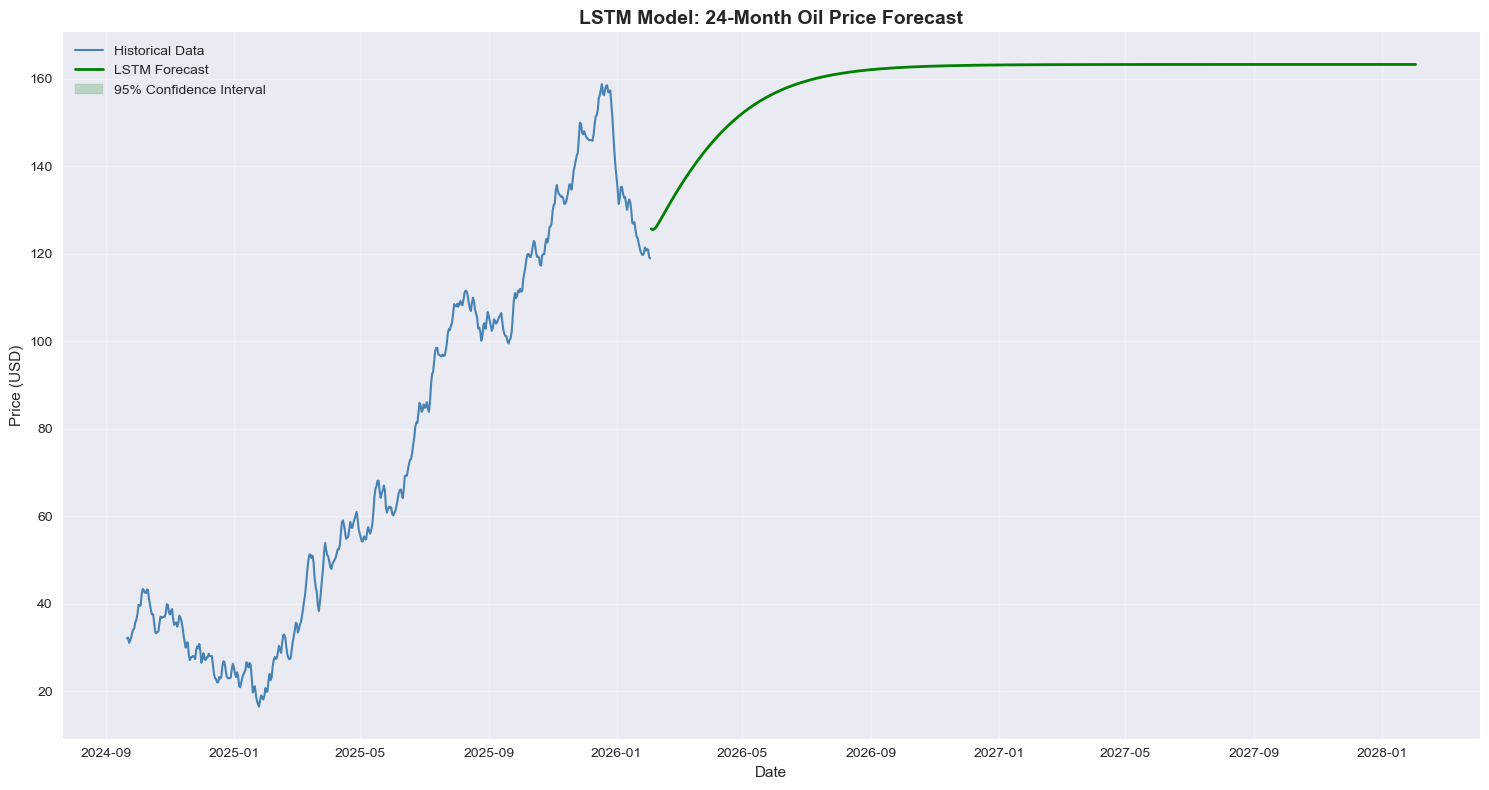

LSTM 24-Month Forecast Summary:
Forecast Start: 2026-02-03
Forecast End: 2028-02-02

Forecast Statistics:
  Mean Forecast: $159.63
  Min Forecast: $125.55
  Max Forecast: $163.28
  Final Forecast: $163.28

Confidence Intervals (final forecast):
  Lower 95%: $163.28
  Point Estimate: $163.28
  Upper 95%: $163.28


In [19]:
# Plot LSTM forecast
plt.figure(figsize=(15, 8))

# Plot historical data
plt.plot(df.index, df['price'], label='Historical Data', 
         color='steelblue', linewidth=1.5)

# Plot forecast
plt.plot(lstm_future_dates, lstm_forecast_mean, label='LSTM Forecast', 
         color='green', linewidth=2)

# Plot confidence intervals
plt.fill_between(lstm_future_dates, 
                 lstm_lower_ci, 
                 lstm_upper_ci,
                 color='green', alpha=0.2, label='95% Confidence Interval')

plt.title('LSTM Model: 24-Month Oil Price Forecast', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('lstm_forecast.png', dpi=300, bbox_inches='tight')
plt.show()

# Print forecast summary
print('LSTM 24-Month Forecast Summary:')
print('=' * 60)
print(f'Forecast Start: {lstm_future_dates[0].strftime("%Y-%m-%d")}')
print(f'Forecast End: {lstm_future_dates[-1].strftime("%Y-%m-%d")}')
print(f'\nForecast Statistics:')
print(f'  Mean Forecast: ${lstm_forecast_mean.mean():.2f}')
print(f'  Min Forecast: ${lstm_forecast_mean.min():.2f}')
print(f'  Max Forecast: ${lstm_forecast_mean.max():.2f}')
print(f'  Final Forecast: ${lstm_forecast_mean[-1]:.2f}')
print(f'\nConfidence Intervals (final forecast):')
print(f'  Lower 95%: ${lstm_lower_ci[-1]:.2f}')
print(f'  Point Estimate: ${lstm_forecast_mean[-1]:.2f}')
print(f'  Upper 95%: ${lstm_upper_ci[-1]:.2f}')

## **20. Model Comparison and Combined Forecast Plot**

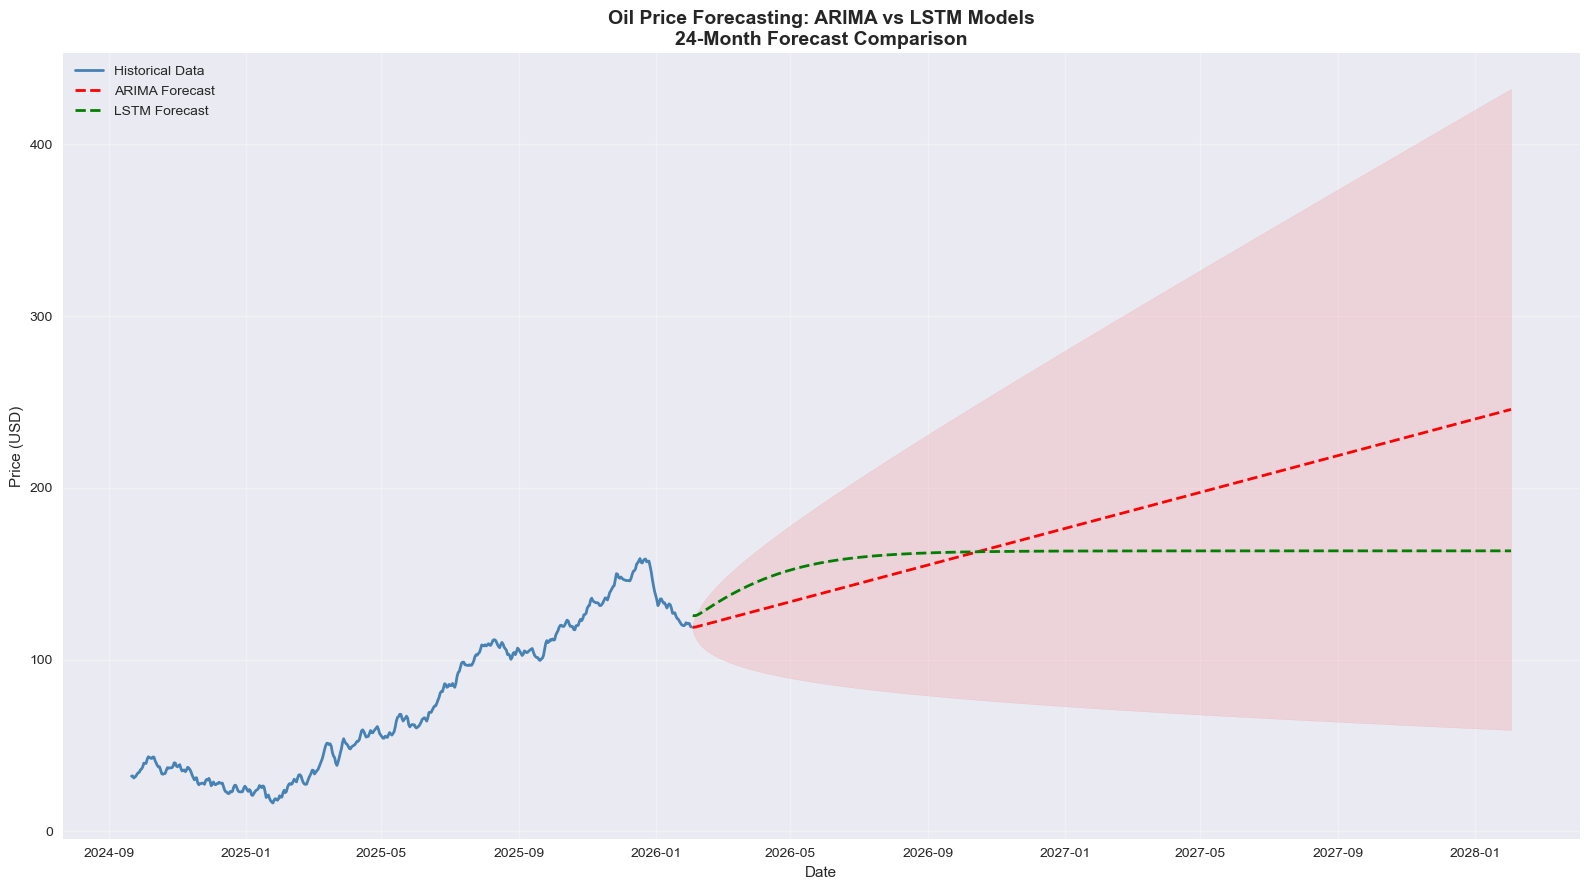

In [20]:
# Combined forecast plot
plt.figure(figsize=(16, 9))

# Plot historical data
plt.plot(df.index, df['price'], label='Historical Data', 
         color='steelblue', linewidth=2)

# Plot ARIMA forecast
plt.plot(future_dates, forecast_mean, label='ARIMA Forecast', 
         color='red', linewidth=2, linestyle='--')
plt.fill_between(future_dates, 
                 forecast_ci.iloc[:, 0], 
                 forecast_ci.iloc[:, 1],
                 color='red', alpha=0.1)

# Plot LSTM forecast
plt.plot(lstm_future_dates, lstm_forecast_mean, label='LSTM Forecast', 
         color='green', linewidth=2, linestyle='--')
plt.fill_between(lstm_future_dates, 
                 lstm_lower_ci, 
                 lstm_upper_ci,
                 color='green', alpha=0.1)

plt.title('Oil Price Forecasting: ARIMA vs LSTM Models\n24-Month Forecast Comparison', 
          fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('combined_forecast_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## **21. Comprehensive Model Comparison Table**

In [21]:
# Create comparison table
comparison_data = {
    'Metric': ['RMSE', 'MAE', 'MAPE (%)', 'AIC', 'Model Type', 
               '24-Month Mean Forecast ($)', '24-Month Final Forecast ($)',
               'Forecast Start', 'Forecast End'],
    'ARIMA': [f'{arima_rmse:.4f}', f'{arima_mae:.4f}', f'{arima_mape:.4f}', 
              f'{best_aic:.2f}', 'Statistical', 
              f'{forecast_mean.mean():.2f}', f'{forecast_mean.iloc[-1]:.2f}',
              future_dates[0].strftime('%Y-%m-%d'),
              future_dates[-1].strftime('%Y-%m-%d')],
    'LSTM': [f'{lstm_rmse:.4f}', f'{lstm_mae:.4f}', f'{lstm_mape:.4f}', 
             'N/A', 'Deep Learning',
             f'{lstm_forecast_mean.mean():.2f}', f'{lstm_forecast_mean[-1]:.2f}',
             lstm_future_dates[0].strftime('%Y-%m-%d'),
             lstm_future_dates[-1].strftime('%Y-%m-%d')]
}

comparison_df = pd.DataFrame(comparison_data)
print('Model Comparison Summary:')
print('=' * 80)
print(comparison_df.to_string(index=False))

# Best model based on metrics
print('\n\nModel Assessment:')
print('=' * 60)
if arima_rmse < lstm_rmse:
    print('ARIMA has lower RMSE - better fit to historical data')
else:
    print('LSTM has lower RMSE - better fit to historical data')

print(f'\nARIMA Parameters: p={best_params[0]}, d={best_params[1]}, q={best_params[2]}')
print(f'LSTM Architecture: 2 LSTM layers (50, 50 units) + Dropout (0.2)')

Model Comparison Summary:
                     Metric       ARIMA          LSTM
                       RMSE      1.8850        8.0742
                        MAE      0.8875        6.3631
                   MAPE (%)      1.8274        4.7444
                        AIC     1429.22           N/A
                 Model Type Statistical Deep Learning
 24-Month Mean Forecast ($)      182.06        159.63
24-Month Final Forecast ($)      245.63        163.28
             Forecast Start  2026-02-03    2026-02-03
               Forecast End  2028-02-02    2028-02-02


Model Assessment:
ARIMA has lower RMSE - better fit to historical data

ARIMA Parameters: p=2, d=2, q=7
LSTM Architecture: 2 LSTM layers (50, 50 units) + Dropout (0.2)


## **22. Seasonal Decomposition Analysis**

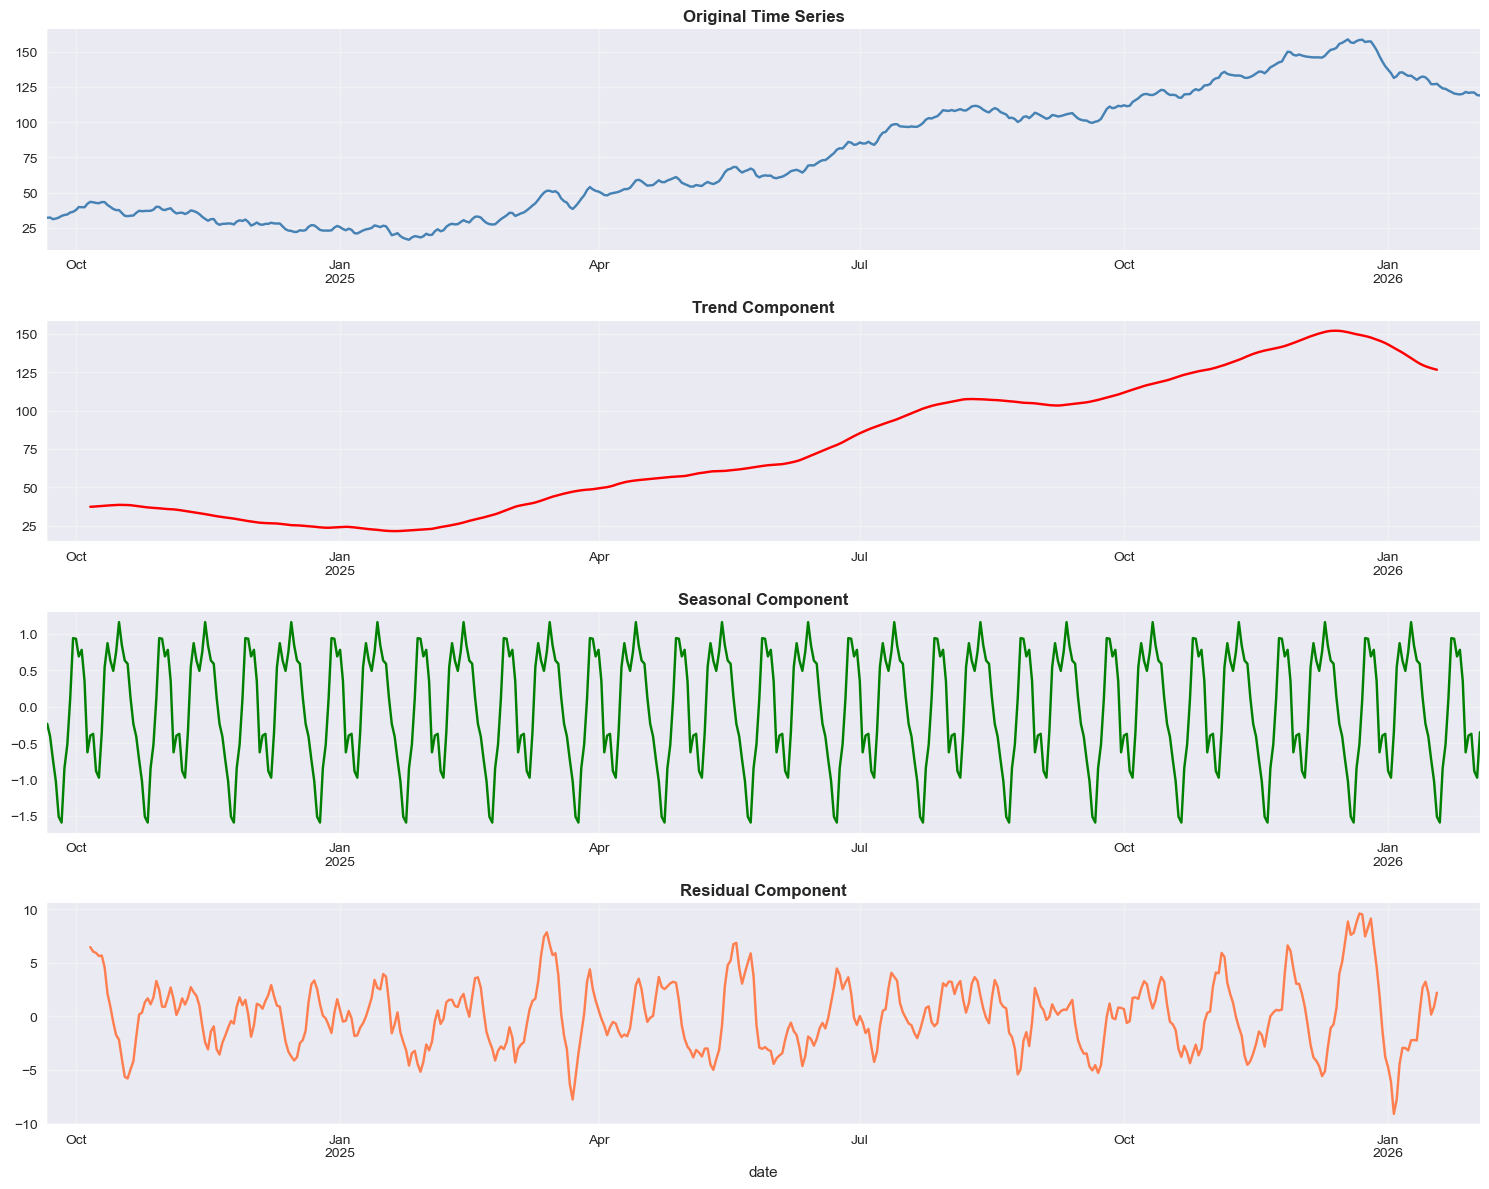

In [22]:
# Seasonal decomposition
decomposition = seasonal_decompose(df['price'], model='additive', period=30)

fig, axes = plt.subplots(4, 1, figsize=(15, 12))

# Original
decomposition.observed.plot(ax=axes[0], color='steelblue')
axes[0].set_title('Original Time Series', fontsize=12, fontweight='bold')
axes[0].set_xlabel('')
axes[0].grid(True, alpha=0.3)

# Trend
decomposition.trend.plot(ax=axes[1], color='red')
axes[1].set_title('Trend Component', fontsize=12, fontweight='bold')
axes[1].set_xlabel('')
axes[1].grid(True, alpha=0.3)

# Seasonal
decomposition.seasonal.plot(ax=axes[2], color='green')
axes[2].set_title('Seasonal Component', fontsize=12, fontweight='bold')
axes[2].set_xlabel('')
axes[2].grid(True, alpha=0.3)

# Residual
decomposition.resid.plot(ax=axes[3], color='coral')
axes[3].set_title('Residual Component', fontsize=12, fontweight='bold')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('seasonal_decomposition.png', dpi=300, bbox_inches='tight')
plt.show()

## **23. Export Results to CSV**

In [23]:
# Export forecasts to CSV
forecast_export = pd.DataFrame({
    'date': future_dates,
    'arima_forecast': forecast_mean.values,
    'arima_lower_ci': forecast_ci.iloc[:, 0].values,
    'arima_upper_ci': forecast_ci.iloc[:, 1].values,
    'lstm_forecast': lstm_forecast_mean,
    'lstm_lower_ci': lstm_lower_ci,
    'lstm_upper_ci': lstm_upper_ci
})

forecast_export.to_csv('oil_price_forecasts.csv', index=False)
print('Forecasts exported to oil_price_forecasts.csv')

# Export model comparison
comparison_df.to_csv('model_comparison.csv', index=False)
print('Model comparison exported to model_comparison.csv')

# Export ARIMA parameter search results
results_df.head(20).to_csv('arima_parameter_search.csv', index=False)
print('ARIMA parameter search results exported to arima_parameter_search.csv')

print('\nAll exports complete!')

Forecasts exported to oil_price_forecasts.csv
Model comparison exported to model_comparison.csv
ARIMA parameter search results exported to arima_parameter_search.csv

All exports complete!


## **24. Final Summary**

In [24]:
print('=' * 80)
print('OIL PRICE FORECASTING PROJECT - FINAL SUMMARY')
print('=' * 80)

print('\n1. DATA OVERVIEW:')
print(f'   - Dataset: {len(df)} daily observations from {df.index.min().date()} to {df.index.max().date()}')
print(f'   - Price Range: ${df["price"].min():.2f} - ${df["price"].max():.2f}')
print(f'   - Mean Price: ${df["price"].mean():.2f}')

print('\n2. STATIONARITY ANALYSIS:')
print('   - Original series: Non-stationary (ADF p-value > 0.05)')
print('   - First differencing: Achieved stationarity')
print(f'   - Best integration order (d): {best_params[1]}')

print('\n3. ARIMA MODEL:')
print(f'   - Optimal Parameters: ARIMA{best_params}')
print(f'   - AIC: {best_aic:.2f}')
print(f'   - In-sample RMSE: {arima_rmse:.4f}')
print(f'   - 24-month forecast mean: ${forecast_mean.mean():.2f}')
print(f'   - Final forecast: ${forecast_mean.iloc[-1]:.2f}')

print('\n4. LSTM MODEL:')
print('   - Architecture: 2 LSTM layers (50 units each) with dropout')
print('   - Lookback window: 60 days')
print(f'   - Test RMSE: {lstm_rmse:.4f}')
print(f'   - 24-month forecast mean: ${lstm_forecast_mean.mean():.2f}')
print(f'   - Final forecast: ${lstm_forecast_mean[-1]:.2f}')

print('\n5. FORECAST PERIOD:')
print(f'   - Start: {future_dates[0].date()}')
print(f'   - End: {future_dates[-1].date()}')
print(f'   - Duration: 24 months (730 days)')

print('\n6. FILES GENERATED:')
print('   - oil_price_forecasts.csv')
print('   - model_comparison.csv')
print('   - arima_parameter_search.csv')
print('   - eda_plots.png')
print('   - acf_pacf_original.png')
print('   - differencing.png')
print('   - acf_pacf_differenced.png')
print('   - arima_residual_diagnostics.png')
print('   - arima_model_fit.png')
print('   - arima_forecast.png')
print('   - lstm_training_history.png')
print('   - lstm_test_predictions.png')
print('   - lstm_forecast.png')
print('   - combined_forecast_comparison.png')
print('   - seasonal_decomposition.png')
print('=' * 80)

OIL PRICE FORECASTING PROJECT - FINAL SUMMARY

1. DATA OVERVIEW:
   - Dataset: 500 daily observations from 2024-09-21 to 2026-02-02
   - Price Range: $16.48 - $158.78
   - Mean Price: $75.87

2. STATIONARITY ANALYSIS:
   - Original series: Non-stationary (ADF p-value > 0.05)
   - First differencing: Achieved stationarity
   - Best integration order (d): 2

3. ARIMA MODEL:
   - Optimal Parameters: ARIMA(2, 2, 7)
   - AIC: 1429.22
   - In-sample RMSE: 1.8850
   - 24-month forecast mean: $182.06
   - Final forecast: $245.63

4. LSTM MODEL:
   - Architecture: 2 LSTM layers (50 units each) with dropout
   - Lookback window: 60 days
   - Test RMSE: 8.0742
   - 24-month forecast mean: $159.63
   - Final forecast: $163.28

5. FORECAST PERIOD:
   - Start: 2026-02-03
   - End: 2028-02-02
   - Duration: 24 months (730 days)

6. FILES GENERATED:
   - oil_price_forecasts.csv
   - model_comparison.csv
   - arima_parameter_search.csv
   - eda_plots.png
   - acf_pacf_original.png
   - differencing.png